## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [0]:
import numpy as np
import pandas as pd
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers.core import Dense,Dropout,Activation,Flatten
from keras.layers.convolutional import Conv2D,MaxPooling2D
from keras.utils import np_utils
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

In [0]:
import tensorflow as tf
tf.reset_default_graph()
tf.set_random_seed(42)

### Find no.of samples are there in training and test datasets

In [91]:
x_train.shape

(60000, 28, 28)

In [92]:
x_test.shape

(10000, 28, 28)

### Find dimensions of an image in the dataset

In [93]:
x_train[0].shape

(28, 28)

In [94]:
x_test[0].shape

(28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train = x_train/255
x_test = x_test/255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:

tf.keras.backend.clear_session()
x_train=x_train.reshape((60000, 28, 28,1))
x_test=x_test.reshape((10000, 28, 28,1))
#Initialize model, reshape & normalize data
model = tf.keras.models.Sequential()

#normalize data
model.add(tf.keras.layers.BatchNormalization())

### Import the necessary layers from keras to build the model

In [0]:
#Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                 kernel_size=(3,3), #Size of the filter
                                 activation='relu',input_shape=(28,28,1)))

#Add second convolutional layer,
model.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))       # Activation funciton helps to do if or else function # Conv2D will acccept 3 dimensional input

#Flatten the output
model.add(tf.keras.layers.Flatten())

#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))  # 128 is a hyper parameter can be defined by user as any value 100/5/10 or anything

#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))


### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [100]:
chpt = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto')

#Train the model
model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,batch_size=10000, callbacks=[chpt] )

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 3s 56us/sample - loss: 1.4613 - acc: 0.4826 - val_loss: 1.6349 - val_acc: 0.4977
Epoch 2/10
60000/60000 [==============================] - 3s 53us/sample - loss: 0.6865 - acc: 0.7495 - val_loss: 1.4207 - val_acc: 0.5496
Epoch 3/10
60000/60000 [==============================] - 3s 53us/sample - loss: 0.5358 - acc: 0.8099 - val_loss: 1.2868 - val_acc: 0.7418
Epoch 4/10
60000/60000 [==============================] - 3s 53us/sample - loss: 0.4610 - acc: 0.8364 - val_loss: 1.2098 - val_acc: 0.7096
Epoch 5/10
60000/60000 [==============================] - 3s 54us/sample - loss: 0.4122 - acc: 0.8536 - val_loss: 1.1063 - val_acc: 0.7799
Epoch 6/10
60000/60000 [==============================] - 3s 55us/sample - loss: 0.3750 - acc: 0.8675 - val_loss: 1.0616 - val_acc: 0.7690
Epoch 7/10
60000/60000 [==============================] - 3s 55us/sample - loss: 0.3482 - acc: 0.8754 - val_loss: 1.

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
tf.keras.backend.clear_session()

#Initialize model, reshape & normalize data
model = tf.keras.models.Sequential()

#Reshape data from 2D (28,28) to 3D (28, 28, 1)
#model.add(tf.keras.layers.Reshape((28,28,1),input_shape=(28,28,)))

#normalize data
model.add(tf.keras.layers.BatchNormalization())

#Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                kernel_size=(3,3), #Size of the filter
                                activation='relu',input_shape=(28,28,1)))

#Add second convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))

#Add MaxPooling layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))


#Flatten the output
model.add(tf.keras.layers.Flatten())

#Add another dropout layer
model.add(tf.keras.layers.Dropout(0.25))

#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))
#model.add(tf.keras.layers.Activation('softmax'))

In [0]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [103]:
chpt = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto')

#Train the model
model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,batch_size=10000, callbacks=[chpt] )

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 4s 68us/sample - loss: 1.5082 - acc: 0.5315 - val_loss: 1.5823 - val_acc: 0.5701
Epoch 2/10
60000/60000 [==============================] - 2s 34us/sample - loss: 0.7224 - acc: 0.7411 - val_loss: 1.0869 - val_acc: 0.6791
Epoch 3/10
60000/60000 [==============================] - 2s 34us/sample - loss: 0.6503 - acc: 0.7630 - val_loss: 0.9460 - val_acc: 0.7476
Epoch 4/10
60000/60000 [==============================] - 2s 34us/sample - loss: 0.5401 - acc: 0.7982 - val_loss: 0.9832 - val_acc: 0.7597
Epoch 5/10
60000/60000 [==============================] - 2s 34us/sample - loss: 0.4896 - acc: 0.8202 - val_loss: 0.9931 - val_acc: 0.7812
Epoch 6/10
60000/60000 [==============================] - 2s 34us/sample - loss: 0.4627 - acc: 0.8346 - val_loss: 0.9420 - val_acc: 0.7865
Epoch 7/10
60000/60000 [==============================] - 2s 35us/sample - loss: 0.4395 - acc: 0.8420 - val_loss: 0.

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

#image genator 
#reshape 
#x_train = x_train.reshape(60000, 28, 28, 1)
#x_test = x_test.reshape(10000, 28, 28, 1)


# compute quantities required for featurewise normalization
# (std, mean, and principal components if ZCA whitening is applied)
datagen.fit(x_train)


#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

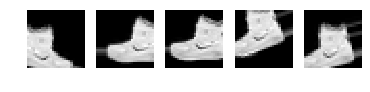

In [108]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [109]:
#Create train and test generator
BS= 1000
model.fit_generator(img_generator.flow(x_train, y_train, batch_size=BS),	validation_data=(x_test,y_test), steps_per_epoch=len(x_train) // BS,	epochs=10)

Epoch 1/10
60/60 [==============================] - 10s 169ms/step - loss: 1.2913 - acc: 0.5530 - val_loss: 1.0904 - val_acc: 0.5708
Epoch 2/10
60/60 [==============================] - 10s 170ms/step - loss: 0.8111 - acc: 0.7053 - val_loss: 1.0520 - val_acc: 0.5698
Epoch 3/10
60/60 [==============================] - 10s 170ms/step - loss: 0.7240 - acc: 0.7362 - val_loss: 0.7361 - val_acc: 0.7388
Epoch 4/10
60/60 [==============================] - 10s 171ms/step - loss: 0.6762 - acc: 0.7500 - val_loss: 0.6210 - val_acc: 0.7649
Epoch 5/10
60/60 [==============================] - 10s 172ms/step - loss: 0.6362 - acc: 0.7649 - val_loss: 0.5269 - val_acc: 0.8069
Epoch 6/10
60/60 [==============================] - 10s 173ms/step - loss: 0.6090 - acc: 0.7741 - val_loss: 0.5293 - val_acc: 0.7944
Epoch 7/10
60/60 [==============================] - 10s 171ms/step - loss: 0.5826 - acc: 0.7844 - val_loss: 0.4965 - val_acc: 0.8156
Epoch 8/10
60/60 [==============================] - 10s 171ms/step - 

###  Report the final train and validation accuracy

In [110]:
print("Final Train accuracy: ", model.evaluate(x_train, y_train)[0]*100)
print("Validation accuracy: ", model.evaluate(x_test,y_test)[0]*100)

60000/60000 [==============================] - 5s 75us/sample - loss: 0.4431 - acc: 0.8361
Final Train accuracy:  44.31261479854584
10000/10000 [==============================] - 1s 74us/sample - loss: 0.4638 - acc: 0.8330
Validation accuracy:  46.37892789363861


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [74]:
from keras.datasets import cifar10
(x1_train, y1_train), (x1_test, y1_test) = cifar10.load_data()

170500096/170498071 [==============================] - 2s 0us/step


### **Load CIFAR10 dataset**

W0818 11:45:27.229168 140624207308672 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 11:45:27.243926 140624207308672 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 11:45:27.256582 140624207308672 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 11:45:27.267746 140624207308672 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 11:45:27.279696 140624207308672 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


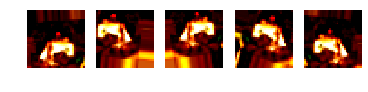

In [78]:
#Prepare/fit the generator.

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
   featurewise_center=True,
   featurewise_std_normalization=True,
   rotation_range=20,
   width_shift_range=0.2,
   height_shift_range=0.2,
   horizontal_flip=True)
#image genator 
#reshape 
x1_train = x1_train.reshape(50000, 32, 32, 3)
x1_test = x1_test.reshape(10000, 32, 32, 3)
# compute quantities required for featurewise normalization
# (std, mean, and principal components if ZCA whitening is applied)

# Prepare/fit the generator.
datagen.fit(x1_train)  
from matplotlib import pyplot as plt
gen = datagen.flow(x1_train[0:1], batch_size=1)

#Generate 5 images for 1 of the image of CIFAR10 train dataset.
